# Исследовательский анализ рынка заведений общественного питания Москвы

- Автор: Комкова Марина
- Дата: 08.04.2026

### Цели и задачи проекта

<font color='#777778'>Провести исследовательский анализ рынка заведений общественного питания Москвы с целью выявления актуальных тенденций, форматов и определиться с характеристиками заведения, чтобы выбрать наиболее подходящую концепцию для инвесторов.
 
 Задачи: 
- Изучить исходные данные и понять их структуру.
- Подготовить данные к анализу: обработать пропуски, исправить ошибки и привести типы данных к нужному виду.
- Провести исследовательский анализ, чтобы выявить особенности рынка (популярные категории, уровень цен, рейтинги, распределение заведений по районам и т.д.).
- На основе анализа сделать выводы и предложить оптимальный формат заведения для открытия.</font>

### Описание данных

Для анализа предоставлены данные, состоящие из двух датасетов: 

**1. rest_info.csv**
- `name` — название заведения  
- `address` — адрес  
- `district` — район  
- `category` — категория  
- `hours` — часы работы  
- `rating` — рейтинг  
- `chain` — сетевое заведение (0/1)  
- `seats` — количество мест  

**2. rest_price.csv**
- `price` — категория цен  
- `avg_bill` — строка со средним чеком  
- `middle_avg_bill` — средний чек  
- `middle_coffee_cup` — цена капучино  

### Содержимое проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговый вывод и рекомендации.

## 1. Загрузка данных и знакомство с ними



Начнём с загрузки библиотек. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn, а также phik для построения матрицы корреляции.

In [1]:
import pandas as pd

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
pip install phik #устанавливанием библиотеку


Note: you may need to restart the kernel to use updated packages.


In [4]:
import phik 

Загружаем датасеты `rest_info` и `reat_price`. Познакомимся с содержим датасетов. 

In [5]:
try: rest_info = pd.read_csv('/datasets/rest_info.csv') 
except: rest_info = pd.read_csv('rest_info.csv') 
try: rest_price = pd.read_csv('/datasets/rest_price.csv') 
except: rest_price = pd.read_csv('rest_price.csv')

In [6]:
rest_info.info()
rest_info.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


Датасет `rest_info` содержит информацию о заведениях общественного питания. Состоит из 9 столбцов и 8406 строк.
После первичного знакомства с данными можно отметить следующее: 
- В столбцах `hours` и `seats` большое количество пропусков.
- Столбец `chain` имеет тип int64, но хранит в себе бинарные значения, можно уменьшить размерность.
- Остальные типы данных представленны корректно.

In [7]:
rest_price.info()
rest_price.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


Датасет `rest_price` содержит информацию о среднем чеке заведений общественного питания и включает 5 столбцов и 4058 строк.

В ходе первичного анализа выявлено следующее:

- В столбцах `price`, `avg_bill`, `middle_avg_bill` и `middle_coffee_cup` присутствует значительное количество пропусков. Особенно большое число пропусков наблюдается в столбце `middle_coffee_cup`.
- Типы данных в целом заданы корректно и соответствуют содержимому столбцов.

### Подготовка единого датафрейма



Объединим данные двух датасетов в датафрейм df

In [8]:

df = rest_info.merge(rest_price, how = 'outer', on = 'id')

Проверим объединение.

In [9]:
df.info()
df.head(5)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


## 2. Предобработка данных

Подготовка данных к исследовательскому анализу.

Проведем преобразование типов данных.

In [10]:
# Снизим разрядность в столбце Chain
df['chain'] = pd.to_numeric(df['chain'], downcast = 'integer')
df['chain'].dtypes

dtype('int8')

- Изучим количество пропусков.

In [11]:
df.isna().sum().sort_values(ascending = False)

middle_coffee_cup    7871
middle_avg_bill      5257
price                5091
avg_bill             4590
seats                3611
hours                 536
id                      0
name                    0
category                0
address                 0
district                0
rating                  0
chain                   0
dtype: int64

In [12]:
# Посчитаем долю пропусков в каждом столбце
pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_share': df.isna().mean() * 100
}).sort_values('missing_share', ascending=False)

,missing_count,missing_share
middle_coffee_cup,7871,93.635498
middle_avg_bill,5257,62.538663
price,5091,60.563883
avg_bill,4590,54.603854
seats,3611,42.957411
hours,536,6.376398
id,0,0.000000
name,0,0.000000
category,0,0.000000
address,0,0.000000


Анализ пропусков показал:

- Наибольшее количество пропусков наблюдается в столбцах, связанных с ценовой информацией:  
  `middle_coffee_cup` — 93.6%,  
  `middle_avg_bill` — 62.5%,  
  `price` — 60.6%,  
  `avg_bill` — 54.6%.  

- Высокая доля пропусков в этих столбцах объясняется особенностями сбора данных: информация о ценах доступна не для всех заведений, а также зависит от наличия соответствующих записей в `avg_bill`.

- Столбец `seats` также содержит значительное количество пропусков (42.9%), что может быть связано с отсутствием информации о количестве посадочных мест.

- В столбце `hours` доля пропусков невелика (6.4%) и не оказывает существенного влияния на анализ.

Таким образом, пропуски в данных носят в основном закономерный характер и связаны с отсутствием дополнительной информации (цены, вместимость), а не с ошибками загрузки данных.


Заменим пропуски в столбца на значения-заглушки.

In [13]:
df['price'] = df['price'].fillna('нет данных')

In [14]:
df['avg_bill'] = df['avg_bill'].fillna('Нет данных')

In [15]:
df['middle_coffee_cup'] = df['middle_coffee_cup'].fillna(-1)

In [16]:
df.isna().sum()/df.shape[0]

id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
hours                0.063764
rating               0.000000
chain                0.000000
seats                0.429574
price                0.000000
avg_bill             0.000000
middle_avg_bill      0.625387
middle_coffee_cup    0.000000
dtype: float64

- Проверка данных на явные и неявные дубликаты.
Приведем содержимое столбцов к нижнему регистру.

In [17]:
columns_to_lower = df.select_dtypes(include='object').columns

df[columns_to_lower] = df[columns_to_lower].apply(lambda col: col.str.lower())

In [18]:
df.head(5)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,wowфли,кафе,"москва, улица дыбенко, 7/1",северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,нет данных,нет данных,NaN,-1.0
1,045780ada3474c57a2112e505d74b633,четыре комнаты,ресторан,"москва, улица дыбенко, 36, корп. 1",северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,средний счёт:1500–1600 ₽,1550.0,-1.0
2,1070b6b59144425896c65889347fcff6,хазри,кафе,"москва, клязьминская улица, 15",северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,средний счёт:от 1000 ₽,1000.0,-1.0
3,03ac7cd772104f65b58b349dc59f03ee,dormouse coffee shop,кофейня,"москва, улица маршала федоренко, 12",северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,нет данных,цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,иль марко,пиццерия,"москва, правобережная улица, 1б",северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,средний счёт:400–600 ₽,500.0,-1.0


Проверим наличие явных дубликатов.

In [19]:
df.duplicated().sum()

0

Явные дубликаты не найдены.

Посчитаем количество неявных дубликатов.

In [20]:
print(df.duplicated(subset = ['name', 'address']).sum())

4


Выведем все дубликаты.

In [21]:
df[df.duplicated(subset=['name', 'address'], keep=False)]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
189,072032ce16dc47bfbc63b672c75bd371,кафе,кафе,"москва, парк ангарские пруды",северный административный округ,"ежедневно, 09:00–23:00",3.2,0,NaN,нет данных,нет данных,NaN,-1.0
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",северный административный округ,"ежедневно, 10:00–22:00",3.2,0,NaN,нет данных,нет данных,NaN,-1.0
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188.0,нет данных,нет данных,NaN,-1.0
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188.0,нет данных,нет данных,NaN,-1.0
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",северо-восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150.0,нет данных,нет данных,NaN,-1.0
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",северо-восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150.0,нет данных,нет данных,NaN,-1.0
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,булочная,"москва, ярцевская улица, 19",западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276.0,нет данных,нет данных,NaN,-1.0
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"москва, ярцевская улица, 19",западный административный округ,NaN,4.1,0,276.0,нет данных,нет данных,NaN,-1.0


Данные различаются по значениям в столбцах `hours` и `category`. 

- Для дальнейшей работы создан столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [22]:
# Создадим функцию, которая возвращает True при условии что в значениях есть слова 'ежедневно' и 'круглосуточно'
def is_24_7(value):
    if pd.isna(value):
        return False
    if 'ежедневно' in value and 'круглосуточно' in value:
        return True
    
    return False

df['is_24_7'] = df['hours'].apply(is_24_7) # Применем функцию к столюцу 'hours'

In [23]:
df['is_24_7'].value_counts()

False    7676
True      730
Name: is_24_7, dtype: int64

---

### Промежуточный вывод



- В ходе предобработки данных явные дубликаты выявлены не были. Обнаружены неявные дубликаты (4 строки), которые отличаются значениями режима работы и категории заведения.
- Были выявлены многочисленные пропуски. В столбцах price, avg_bill, middle_avg_bill, middle_coffee_cup пропуски были заменены на значения-заглушки.
- Пропуски в столбцах hours и seats оставлены без изменений, чтобы избежать искажения данных.
- Создан дополнительный столбец, содержащий информацию о том, является ли заведение круглосуточным.

## 3. Исследовательский анализ данных
Проведите исследовательский анализ исходных данных.

При исследовании данных используйте визуализации. Проверьте, что для каждого случая подобран оптимальный тип визуализации с корректным оформлением. У графика должен быть заголовок, понятные подписи по осям, при необходимости легенда, а его размер является оптимальным для изучения.

После исследования каждого пункта оставляйте небольшой комментарий с выводом или обсуждением результата. В конце шага обобщите результаты, выделив, по вашему мнению, самые важные.

---

### Задача 1

Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.

In [24]:
df['category'].value_counts().sort_values(ascending = False)

кафе               2378
ресторан           2043
кофейня            1413
бар,паб             765
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64

In [25]:
round(df['category'].value_counts(normalize = True),2)

кафе               0.28
ресторан           0.24
кофейня            0.17
бар,паб            0.09
пиццерия           0.08
быстрое питание    0.07
столовая           0.04
булочная           0.03
Name: category, dtype: float64

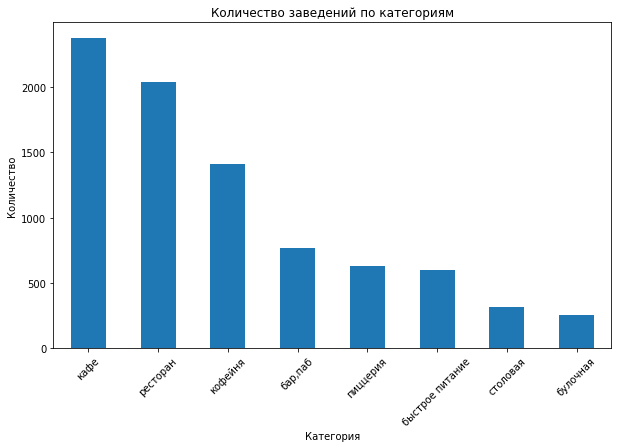

In [26]:
df['category'].value_counts().sort_values(ascending = False).plot(kind = 'bar',
        title = 'Количество заведений по категориям',
        xlabel = 'Категория',
        ylabel = 'Количество',
        figsize = (10,6),
        rot = 45)
plt.show()

**Количество заведений по категориям:**
- кафе               2378
- ресторан           2043
- кофейня            1413
- бар,паб             765
- пиццерия            633
- быстрое питание     603
- столовая            315
- булочная            256

**Доля заведений по категориям:** 
- кафе               0.28
- ресторан           0.24
- кофейня            0.17
- бар,паб            0.09
- пиццерия           0.08
- быстрое питание    0.07
- столовая           0.04
- булочная           0.03

**Самая распространенная категория заведений - кафе - 2378 заведений, доля 28%, следующими идут ресторан (2043, 24%), кофейни (1413, 17%).
Наименее распространенные заведения - булочные(256, 3%).**

---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

In [27]:
# Посчитаем количество заведений в каждом районе Москвы
df['district'].value_counts()

центральный административный округ         2242
северный административный округ             900
южный административный округ                892
северо-восточный административный округ     891
западный административный округ             851
восточный административный округ            798
юго-восточный административный округ        714
юго-западный административный округ         709
северо-западный административный округ      409
Name: district, dtype: int64

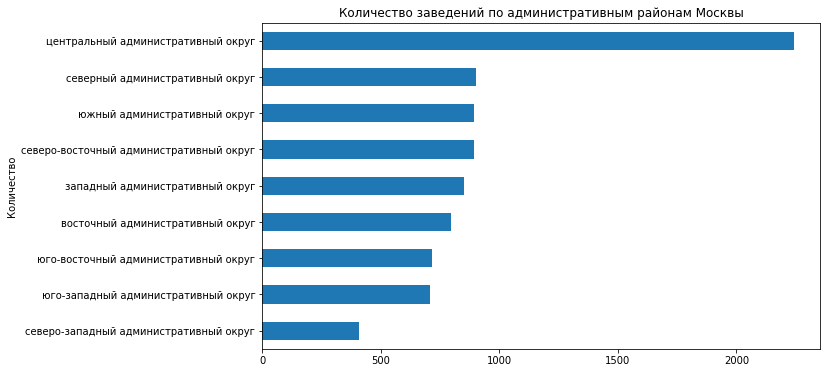

In [28]:
df['district'].value_counts().sort_values().plot(kind = 'barh',
                                   title = 'Количество заведений по административным районам Москвы',
                                   xlabel = 'Количество',
                                   ylabel = 'Районы Москвы',
                                   figsize = (10,6),
                                   rot = 0)
plt.show()

Район с самым большим количеством заведений - ЦАО (2242 заведения), при этом следующие районы по популярности САО, ЮАО имеют в два раза меньше заведений - 900, 892. Меньше всего заведений в Северо-Западном АО - 409.
Рассмотрим какие категории заведений представлены в ЦАО и в каком количестве.

In [29]:
df_center = df[df['district'] == 'центральный административный округ']
df_center['category'].value_counts() 


ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: category, dtype: int64

<AxesSubplot:title={'center':'Количество заведений по категориям в центральном административном округе'}, ylabel='Количество'>

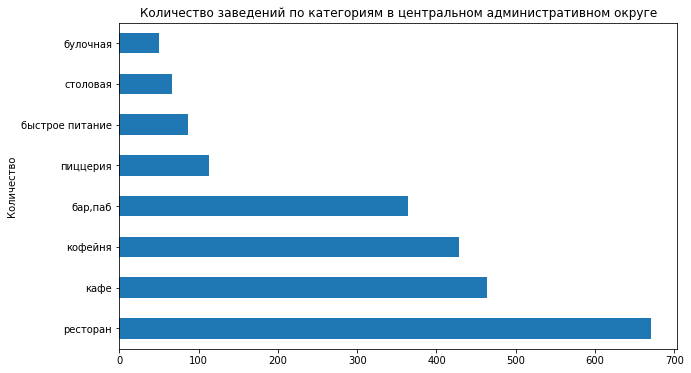

In [30]:
df_center = df[df['district'] == 'центральный административный округ']
category_counts = df_center['category'].value_counts() 
category_counts.plot(kind = 'barh',
                                   title = 'Количество заведений по категориям в центральном административном округе',
                                   xlabel = 'Количество',
                                   ylabel = 'Категории',
                                   figsize = (10,6),
                                   rot = 0)

В ЦАО самое большое количество заведений являются ресторанами - 670, дальше по популярности кафе и кофейни - 464, 428. Самые немногочисленные это столовая - 66 и булочная 55.

**Количество заведений по административным районам Москвы:**
- центральный административный округ         2242
- северный административный округ             900
- южный административный округ                892
- северо-восточный административный округ     891
- западный административный округ             851
- восточный административный округ            798
- юго-восточный административный округ        714
- юго-западный административный округ         709
- северо-западный административный округ      409

**Категории заведений в ЦАО:**
- ресторан           670
- кафе               464
- кофейня            428
- бар,паб            364
- пиццерия           113
- быстрое питание     87
- столовая            66
- булочная            50

---

### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

In [31]:
df.shape[0]

8406

In [32]:
# Считаем количество заведений сетевых (1) и несетевых (0)
df['chain'].value_counts()

0    5201
1    3205
Name: chain, dtype: int64

In [33]:
df['chain'].value_counts()/df.shape[0]

0    0.618725
1    0.381275
Name: chain, dtype: float64

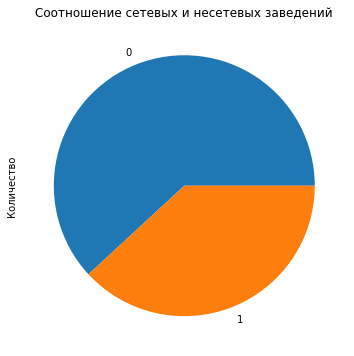

In [34]:
df['chain'].value_counts().plot(kind = 'pie',
                                   title = 'Соотношение сетевых и несетевых заведений',
                                   ylabel = 'Количество',
                                   figsize = (10,6),
                                   rot = 0)
plt.show()

В ходе анализа выявлено, что большинство заведений (около 62%) не являются сетевыми. Рассмотрим в разрезе категорий заведений.

In [35]:
 # Построим сводную таблицу, где посчитаем количество сетевых и несетевых заведений в каждой категории.
pd.crosstab(df['category'], df['chain'])

chain,0,1
category,,
"бар,паб",596,169
булочная,99,157
быстрое питание,371,232
кафе,1599,779
кофейня,693,720
пиццерия,303,330
ресторан,1313,730
столовая,227,88


In [36]:
# Для наглядности выведем данные в процентах
pd.crosstab(df['category'], df['chain'], normalize='index') * 100

chain,0,1
category,,
"бар,паб",77.908497,22.091503
булочная,38.671875,61.328125
быстрое питание,61.525705,38.474295
кафе,67.241379,32.758621
кофейня,49.044586,50.955414
пиццерия,47.867299,52.132701
ресторан,64.268233,35.731767
столовая,72.063492,27.936508


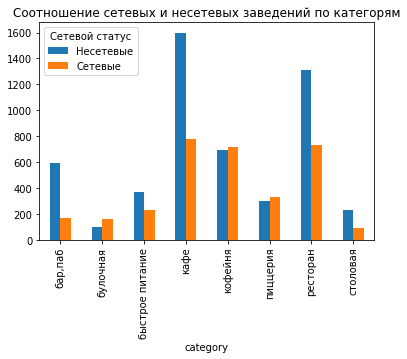

In [37]:
df_unstack = df.groupby('category')['chain'].value_counts().unstack(fill_value=0)
df_unstack.plot(kind='bar', title = 'Соотношение сетевых и несетевых заведений по категорям') 
plt.legend(title='Сетевой статус', labels=['Несетевые', 'Сетевые'])

<AxesSubplot:title={'center':'Процент сетевых заведений по категорям'}, xlabel='category'>

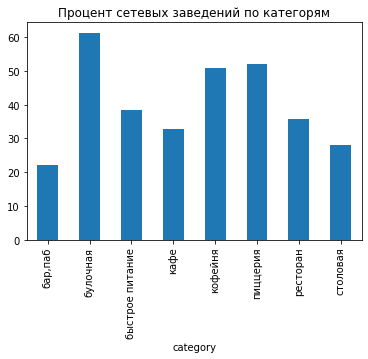

In [38]:
df_net = (df[df['chain'] == 1].groupby('category').size()
 / df.groupby('category').size()) * 100
df_net.plot(kind='bar', title = 'Процент сетевых заведений по категорям') 

**Количество сетевых заведений - 3205 это 38% процентов от общего количества заведений. Несетевых заведений - 5201, что составляет 62%.
Чаще сетевыми являются булочные - доля сетевых заведений составляет 61%,
пиццерии - 52% и кофейни - 50%.**

---

### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


In [39]:
df['seats'].describe()

count    4795.000000
mean      108.421689
std       122.833396
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

Среднее значение количества посадочных мест - 108, значение медианы 75, такая разница возможна из-за аномально высоких значений или выбросов. Максимальное значение - 1288 мест. Построим диаграмму размаха.

<AxesSubplot:>

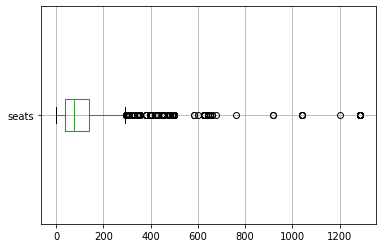

In [40]:
df.boxplot(column = 'seats', vert = False)

В данных наблюдаются выбросы в виде аномально больших значений количества посадочных мест. Они могут быть связаны с наличием крупных ресторанов, банкетных залов или заведений, расположенных в торговых центрах и рассчитанных на большой поток посетителей. 

In [41]:
seats_by_category = df.groupby('category')['seats'].median().sort_values()
print(seats_by_category)

category
булочная           50.0
пиццерия           55.0
кафе               60.0
быстрое питание    65.0
столовая           75.5
кофейня            80.0
бар,паб            82.5
ресторан           86.0
Name: seats, dtype: float64


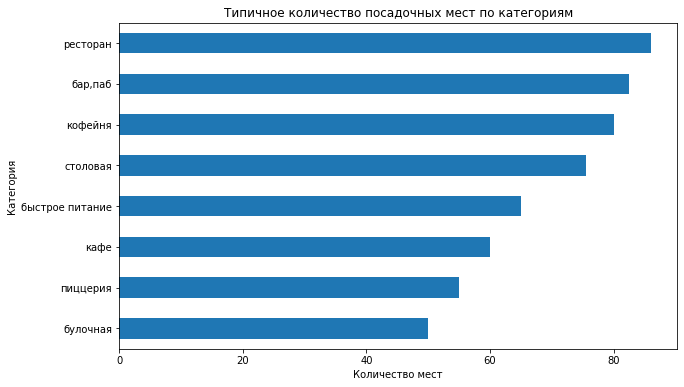

In [42]:
seats_by_category.plot(kind='barh', figsize=(10,6))

plt.title('Типичное количество посадочных мест по категориям')
plt.xlabel('Количество мест')
plt.ylabel('Категория')
plt.show()

**Типичное количество посадочных мест для каждой категории:**
- булочная           50
- пиццерия           55
- кафе               60
- быстрое питание    65
- столовая           75
- кофейня            80
- бар,паб            82
- ресторан           86

---

### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

In [43]:
round(df.groupby('category')['rating'].mean().sort_values(ascending = False),2)

category
бар,паб            4.39
пиццерия           4.30
ресторан           4.29
кофейня            4.28
булочная           4.27
столовая           4.21
кафе               4.12
быстрое питание    4.05
Name: rating, dtype: float64

 Заведения бар, паб имеют самый высокий средний рейтинг - 4,39, пиццерия - 4,3, ресторан 4,29. Самый низкий рейтинг принадлежит заведениям быстрого питания - 4,05

4.23


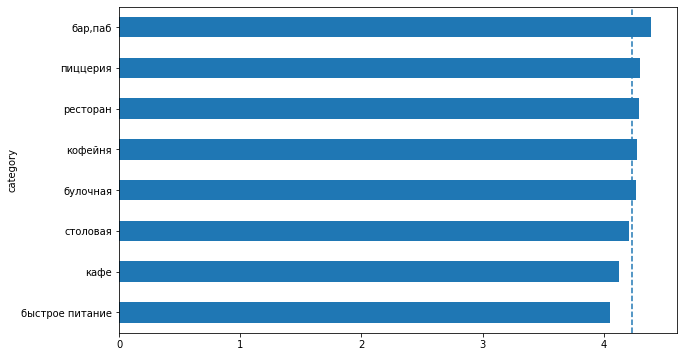

In [44]:
mean_rating = df['rating'].mean()

rating_bar = df.groupby('category')['rating'].mean().sort_values().plot(kind='barh', figsize=(10,6), ylabel='Категория')

rating_bar.axvline(mean_rating, linestyle='--')
print(round(mean_rating, 2))

In [45]:
round((df.groupby('category')['rating'].mean().sort_values(ascending = False) - mean_rating),2)

category
бар,паб            0.16
пиццерия           0.07
ресторан           0.06
кофейня            0.05
булочная           0.04
столовая          -0.02
кафе              -0.11
быстрое питание   -0.18
Name: rating, dtype: float64

Отклонения среднего рейтинга по категориям незначительны и находятся в пределах ±0,2, что говорит о в целом однородном уровне качества заведений.

**Средний рейтинг по всем категорям - 4,23.**

**Средние рейтинги для каждой категории:**
- бар,паб            4.39
- пиццерия           4.30
- ресторан           4.29
- кофейня            4.28
- булочная           4.27
- столовая           4.21
- кафе               4.12
- быстрое питание    4.05

**Отклонения среднего рейтинга по категориям:**
- бар,паб            0.16
- пиццерия           0.07
- ресторан           0.06
- кофейня            0.05
- булочная           0.04
- столовая          -0.02
- кафе              -0.11
- быстрое питание   -0.18

**Отклонения среднего рейтинга по категориям незначительны и находятся в пределах ±0,2, что говорит о в целом однородном уровне качества заведений.**

**Наиболее низкие значения наблюдаются у заведений быстрого питания (−0,18) и кафе (−0,11), что может быть связано с высоким потоком посетителей и менее стабильным качеством сервиса.**

**Наиболее высокие отклонения зафиксированы у баров и пабов (+0,16), а также у пиццерий и ресторанов, что может объясняться большей ориентацией на атмосферу и клиентский опыт.**

---

### Задача 6

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

In [46]:
cols = ['rating', 'category', 'district', 'chain', 'seats', 'price', 'is_24_7']

corr_matrix = df[cols].phik_matrix(interval_cols=['rating', 'seats'])

print(round(corr_matrix['rating'].sort_values(ascending=False), 2))

rating      1.00
price       0.28
district    0.20
category    0.19
is_24_7     0.15
chain       0.11
seats       0.00
Name: rating, dtype: float64


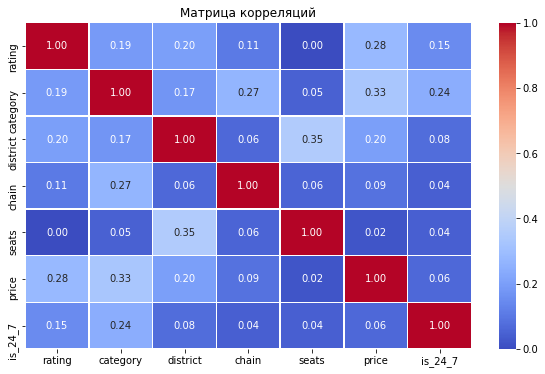

In [47]:
plt.figure(figsize=(10,6))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5 )
plt.title('Матрица корреляций')
plt.show()


**Коэффициент корреляции:**
- rating      1.00
- price       0.28
- district    0.20
- category    0.19
- is_24_7     0.15
- chain       0.11
- seats       0.00

**Анализ корреляции показал, что значимых зависимостей между рейтингом заведений и рассмотренными признаками не выявлено: все значения находятся в диапазоне слабых связей (менее 0.3).**

**Наибольшая связь наблюдается между рейтингом и ценовой категорией (0.28), что может указывать на тенденцию более высоких оценок у заведений с более высоким средним чеком. Слабая зависимость также прослеживается с районом (0.20) и категорией заведения (0.19).**

**Минимальная или практически отсутствующая связь наблюдается с сетевым статусом (0.11), режимом работы (0.15) и количеством посадочных мест (0.00), что говорит о том, что данные факторы практически не влияют на рейтинг.**


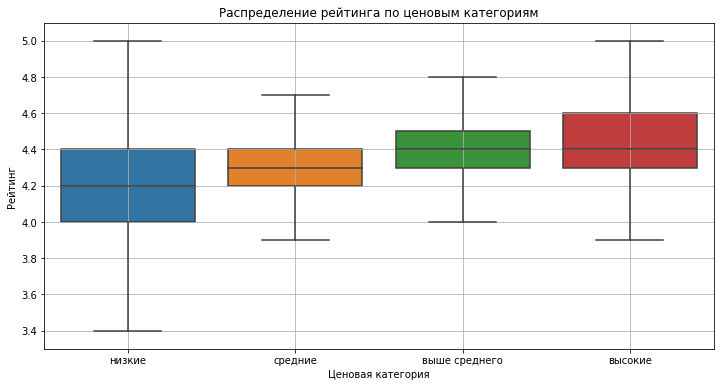

In [48]:
df = df[df['price'] != 'нет данных']
plt.figure(figsize=(12,6))
sns.boxplot( data= df, x='price', y='rating', order = ['низкие','средние','выше среднего','высокие'], showfliers=False)
plt.xlabel('Ценовая категория')
plt.ylabel('Рейтинг')
plt.ylim(3.3, 5.1)
plt.grid(True)
plt.title('Распределение рейтинга по ценовым категориям')
plt.show()

**Медианный рейтинг растёт вместе с ценовой категорией: для заведений с низкими ценами рейтинг составляет 4,2, со средними — 4,3, для категорий «выше среднего» и «высокие» — 4,4.**

**При этом медианы категорий «выше среднего» и «высокие» совпадают - после определённого уровня рост цены уже не сопровождается ростом рейтинга.**

**Также заметно, что в категории низких цен наблюдается больший разброс значений, что может говорить о менее стабильном качестве.
При этом распределения существенно пересекаются, поэтому зависимость нельзя считать сильной.**

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

In [49]:
counts = df[df['chain']==1]['name'].value_counts().head(15)

ratings = round(df[df['chain']==1].groupby('name')['rating'].mean(),2)

result = counts.to_frame('count').merge(ratings.to_frame('rating'), left_index=True, right_index=True)

print(result)

                                     count  rating
шоколадница                             52    4.17
домино'с пицца                          39    4.18
кулинарная лавка братьев караваевых     28    4.40
prime                                   24    4.13
хинкальная                              23    4.36
теремок                                 20    4.18
му-му                                   19    4.27
кофемания                               16    4.41
vasilchukí chaihona №1                  15    4.36
андерсон                                13    4.48
чайхана                                 12    4.09
вареничная № 1                          12    4.37
мск lounge                              12    4.43
джонджоли                               12    4.42
алло! пицца                             11    4.29


4.3


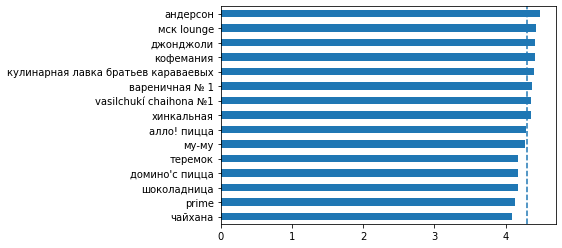

In [50]:
mean_ratings = result['rating'].mean()
ax = avg_rating = result['rating'].sort_values().plot(kind='barh')
ax.axvline(mean_ratings, linestyle = '--')
print(round(mean_ratings, 2))

In [51]:
counts = df[df['chain'] == 1]['name'].value_counts().head(15)
category = df[df['chain'] == 1].groupby('name')['category'].first()
result = counts.to_frame('count').merge( category.to_frame('category'), left_index=True, right_index=True)
result = result.sort_values(by='count', ascending=False)
print(result)


                                     count  category
шоколадница                             52   кофейня
домино'с пицца                          39  пиццерия
кулинарная лавка братьев караваевых     28      кафе
prime                                   24  ресторан
хинкальная                              23      кафе
теремок                                 20  ресторан
му-му                                   19      кафе
кофемания                               16   кофейня
vasilchukí chaihona №1                  15  ресторан
андерсон                                13  ресторан
чайхана                                 12      кафе
вареничная № 1                          12      кафе
мск lounge                              12   бар,паб
джонджоли                               12  ресторан
алло! пицца                             11  пиццерия


**Топ 15 популярных сетей в Москве:** (количество и средний рейтинг)

- шоколадница                            120    4.18
- домино'с пицца                          76    4.17
- додо пицца                              74    4.29
- one price coffee                        71    4.06
- яндекс лавка                            69    3.87
- cofix                                   65    4.08
- prime                                   50    4.12
- хинкальная                              44    4.32
- кофепорт                                42    4.15
- кулинарная лавка братьев караваевых     39    4.39
- теремок                                 38    4.12
- чайхана                                 37    3.92
- cofefest                                32    3.98
- буханка                                 32    4.40
- му-му                                   27    4.23

**Категории Топ 15 популярных сетей в Москве:**

- шоколадница                            120          кофейня
- домино'с пицца                          76         пиццерия
- додо пицца                              74         пиццерия
- one price coffee                        71          кофейня
- яндекс лавка                            69         ресторан
- cofix                                   65          кофейня
- prime                                   50         ресторан
- хинкальная                              44  быстрое питание
- кофепорт                                42          кофейня
- кулинарная лавка братьев караваевых     39             кафе
- теремок                                 38         ресторан
- чайхана                                 37             кафе
- cofefest                                32          кофейня
- буханка                                 32         булочная
- му-му                                   27             кафе


Самая популярная сеть - шоколадница имеет 120 заведений, при этом средний рейтинг - 4.18, категория заведения - кофейня.  Наименее популярная сеть муму - 27 заведений, средний рейтинг - 4.2, категория заведения - кафе. Самый высокий средний рейтинг у заведений буханка - 4.40, 32 заведения, ккатегория - булочная. 
Среди топ-15 популярных сетей преобладают кофейни, пиццерии, кафе и рестораны, что отражает востребованность этих форматов и их потенциал для масштабирования. Особенно заметно присутствие кофеен — они составляют значительную часть самых распространённых сетей.

---

### Задача 8

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.


In [52]:
bill_median = round(df.groupby('district')['middle_avg_bill'].median().sort_values(ascending = False),2) 
print(bill_median)


district
западный административный округ            1000.0
центральный административный округ         1000.0
северо-западный административный округ      850.0
северный административный округ             750.0
восточный административный округ            725.0
юго-западный административный округ         687.5
южный административный округ                587.5
северо-восточный административный округ     575.0
юго-восточный административный округ        537.5
Name: middle_avg_bill, dtype: float64


Самые высокие медианные чеки в ЦАО и ЗАО - 1000.0, самые низкие в СВАО - 575, ЮВАО - 537,5.

Подробнее сравним средний чек в ЦАО и ЗАО:

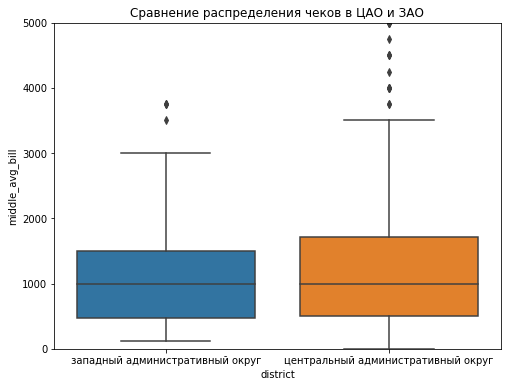

In [53]:
cao_zao = df[df['district'].isin(['центральный административный округ', 'западный административный округ'])]


plt.figure(figsize=(8,6))

sns.boxplot(data=cao_zao, x='district', y='middle_avg_bill')

plt.ylim(0,5000)
plt.title('Сравнение распределения чеков в ЦАО и ЗАО')
plt.show()

При одинаковой медиане (1000 руб.) округа отличаются структурой цен. В ЦАО наблюдается больший разброс, более высокий верхний квартиль и больше дорогих выбросов, что указывает на наличие большого количества дорогих завденией. В ЗАО распределение более однородно. 

Построим график среднего чека по районам Москвы для расчета используем медиану.

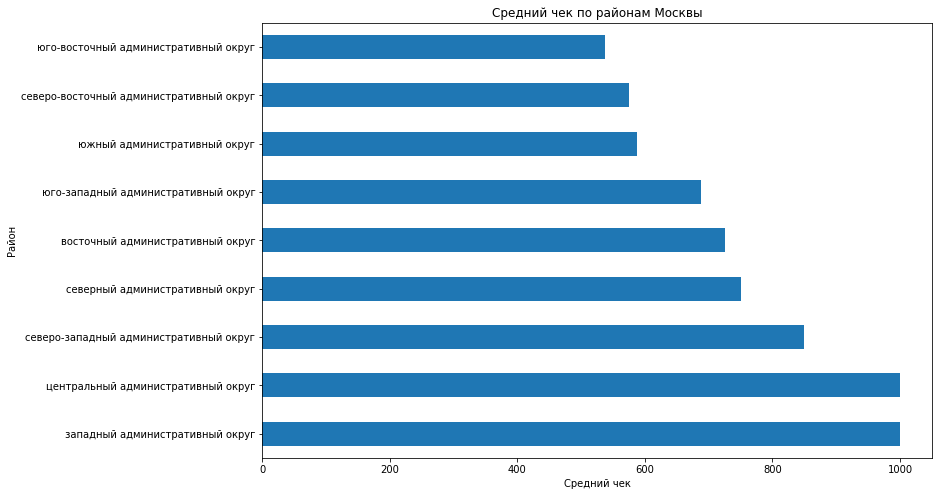

In [54]:
df.groupby('district')['middle_avg_bill'].median().sort_values(ascending = False).plot(kind='barh', figsize=(12,8))

plt.title('Средний чек по районам Москвы')
plt.xlabel('Средний чек')
plt.ylabel('Район')
plt.show()

Расчитаем процентную разницу среднего чека в ЦАО и других районах.

In [55]:
df_cao = df[df['district'] == 'центральный административный округ']
df_other = df[df['district'] != 'центральный административный округ']
cao_median = df_cao['middle_avg_bill'].median()
other_median = df_other['middle_avg_bill'].median()
ratio = (cao_median - other_median) / other_median * 100

print(round(ratio,2))


42.86


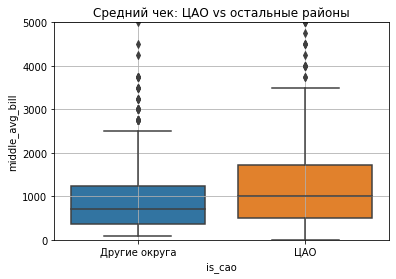

In [56]:
def cao(x):
    if x == 'центральный административный округ':
        return 'ЦАО'
    else:
        return 'Другие округа'

df['is_cao'] = df['district'].apply(cao)

sns.boxplot(data=df, x='is_cao', y='middle_avg_bill')
plt.ylim(0, 5000)
plt.grid(True)
plt.title('Средний чек: ЦАО vs остальные районы')
plt.show()

Средний чек по районам Москвы: 
- западный административный округ            1000.0
- центральный административный округ         1000.0
- северо-западный административный округ      850.0
- северный административный округ             750.0
- восточный административный округ            725.0
- юго-западный административный округ         687.5
- южный административный округ                587.5
- северо-восточный административный округ     575.0
- юго-восточный административный округ        537.5

По медианному чеку самые высокие значения наблюдаются в Центральном и Западном административных округах — по 1000 руб., далее идет Северо-Западный округ — 850 руб. Самые низкие медианные чеки зафиксированы в ЮВАО — 537.5 руб., СВАО — 575 руб. и ЮАО — 587.5 руб. Это говорит о том, что в целом по мере удаления от центра уровень цен снижается.

Отдельно сравнила ЦАО и остальные округа: медианный чек в ЦАО оказался на 42.86% выше, чем в остальных округах, что подтверждает более высокий уровень цен в центре.

При этом зависимость нельзя назвать строго линейной. ЗАО имеет такой же медианный чек, как и ЦАО (1000 руб.), что можно объяснить престижностью округа и концентрацией более дорогих заведений. То есть на уровень цен влияет не только удалённость от центра, но и характеристики самого округа.

Дополнительное сравнение ЦАО и ЗАО показало, что при одинаковой медиане структура цен у них различается: в ЦАО выше разброс цен, выше верхний квартиль и больше дорогих выбросов, что говорит о более выраженном премиальном сегменте. В ЗАО распределение более однородное.

Таким образом, можно сделать вывод, что удалённость от центра в целом связана со снижением среднего чека, но эта зависимость не строгая, так как на цены влияет также престижность района.


---

### Промежуточный вывод



В ходе анализа рынка общественного питания Москвы были изучены основные характеристики заведений: категории, расположение, сетевой статус, ценовой уровень, посадочные места и рейтинги.

Рынок в основном представлен кафе, ресторанами и кофейнями, при этом около 62% заведений являются несетевыми. Наиболее активно сетевые форматы развиваются в булочных, пиццериях и кофейнях.

Средний рейтинг заведений стабилен и составляет около 4,23, при этом различия между категориями незначительны. Наиболее высокие оценки характерны для баров и пабов, а наиболее низкие — для кафе и заведений быстрого питания.

Корреляционный анализ показал отсутствие сильных зависимостей рейтинга от исследуемых факторов. Наибольшая, но слабая связь наблюдается с ценовой категорией, тогда как остальные признаки практически не влияют на рейтинг.

Также выявлено, что популярные сети сосредоточены в категориях кафе, кофеен и ресторанов, а уровень цен существенно зависит от расположения: в Центральном административном округе средний чек на ~41,8% выше, чем в других районах.


## 4. Итоговый вывод и рекомендации

По результатам проведённого исследовательского анализа данных сформулируйте итоговый вывод и рекомендации для заказчика. Старайтесь акцентировать внимание на ключевых моментах исследования.

При составлении вывода придерживайтесь такой структуры:

1. Общий обзор проделанной работы.
2. Ответы на исследовательские вопросы, или главные выводы.
3. Рекомендации на основе анализа данных.

1. Общий обзор проделанной работы

- Были загружены два датасета `rest_info` и `rest_price`, объединены в единый датафрейм `df`.
- Итоговый датасет содержит 8406 строк и 13 столбцов с информацией о заведениях: название, адрес, район, категория, количество посадочных мест, рейтинг, часы работы, сетевой статус и средний чек.
- Типы данных: float64 (4), int64 (1), object (8).
- Проведено преобразование типа данных в столбце Chain (снижение разрядности).
- Обнаружены пропуски, наибольшие из них в ценовых показателях:
`middle_coffee_cup` — 93.6%
`middle_avg_bill` — 62.5%
`price` — 60.6%
`avg_bill` — 54.6%
- В столбцах `price`, `avg_bill`, `middle_coffee_cup` пропуски заменены заглушками.
- Явных дубликатов не обнаружено, выявлено 4 неявных дубликата, отличающихся значениями в house и category.
- Создан столбец `is_24_7`, отражающий круглосуточную работу заведения.
- Проведён исследовательский анализ данных и сформированы рекомендации.

2. Исследовательский анализ данных

Категории заведений.
Наиболее распространённые категории:
- кафе — 2378 (28%)
- рестораны — 2043 (24%)
- кофейни — 1413 (17%)

География:
В данных представлено 9 административных округов. 
Лидирует:
- ЦАО — 2242 заведения
- САО — 900
- ЮАО — 892
Минимум:
- СЗАО — 409
В ЦАО преобладают:
- рестораны — 670
- кафе — 464
- кофейни — 428

Сетевые и несетевые заведения
- Сетевые — 3205 (38%)
- Несетевые — 5201 (62%)

Наиболее «сетевые» категории:
- булочные — 61%
- пиццерии — 52%
- кофейни — 50%

Посадочные места (средние значения):
- булочная — 50
- пиццерия — 55
- кафе — 60
- быстрое питание — 65
- столовая — 75
- кофейня — 80
- бар/паб — 82
- ресторан — 86

Рейтинги по категориям:
- бар/паб — 4.39
- пиццерия — 4.30
- ресторан — 4.29
- кофейня — 4.28
- булочная — 4.27
- столовая — 4.21
- кафе — 4.12
- быстрое питание — 4.05

Отклонения рейтингов незначительные (в пределах ±0.2), что говорит об относительно равном уровне качества.
Выше среднего: бары и пабы (+0.16)
Ниже среднего: fast food (−0.18), кафе (−0.11)

Корреляционный анализ

Связь рейтинга с признаками слабая:
- price — 0.28 (максимальная связь)
- district — 0.20
- category — 0.19
- is_24_7 — 0.15
- chain — 0.11
- seats — 0.00
Рейтинг практически не зависит от большинства факторов.

Влияние цены на рейтинг:
- низкая цена — 4.2
- средняя — 4.3
- выше среднего / высокая — 4.4
После достижения уровня «выше среднего» рост цены не увеличивает рейтинг. Разброс в низком сегменте выше, что говорит о нестабильном качестве.

Сетевые заведения (топ-15):
Лидеры:

- Шоколадница — 120 (4.18)
- Домино’с Пицца — 76 (4.17)
- Додо Пицца — 74 (4.29)
- One Price Coffee — 71 (4.06)
Доминируют кофейни, пиццерии и кафе. 

Средний чек по районам
Максимальные значения:
- ЦАО — 1000
- ЗАО — 1000

Минимальные:
- ЮВАО — 537.5
- СВАО — 575
- ЮАО — 587.5
В среднем чек снижается по мере удаления от центра, но зависимость не строго линейная.

Дополнительно:
ЦАО и ЗАО имеют одинаковую медиану, но в ЦАО выше разброс и больше дорогих заведений (премиальный сегмент выражен сильнее).

3. Рекомендации для заказчика
Наиболее перспективные форматы для открытия:
- кофейни, пиццерии и кафе
эти категории уже доказали высокую популярность и масштабируемость.
Особенно эффективно развивать сетевые форматы.
Выбор района:
- ЦАО — максимальный поток и высокий чек, но высокая конкуренция и высокая стоимость входа
- ЗАО — аналогичный уровень среднего чека при потенциально более стабильной структуре рынка
- САО и ЮАО — оптимальный баланс между спросом и конкуренцией
- окраинные районы — ниже чек, но возможен рост за счёт нехватки качественных заведений
Ценовая стратегия:
- оптимальный сегмент: средний и выше среднего чек (4.3–4.4 рейтинг без ухудшения восприятия цены)
- премиальный сегмент оправдан в центре и ЗАО
- низкий ценовой сегмент менее стабилен по качеству и рейтингу

Режим работы 24/7 не влияет на рейтинг - нет смысла делать его обязательным фактором успеха
Количество посадочных мест не влияет на рейтинг - можно гибко выбирать формат помещения